# 02 · Data Visualization

Temporal trends, budget composition, and cross-country heatmaps built on the reusable `globalbudget.viz` helpers (consistent theme + colour-blind-friendly category palette).

In [1]:
import sys
from pathlib import Path
# Locate the project root (the folder containing src/globalbudget) and add src to path.
_p = Path.cwd()
while _p != _p.parent and not (_p / "src" / "globalbudget").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from globalbudget import data_loader, cleaning, features, viz, forecasting
viz.set_theme()
pd.set_option("display.max_columns", 40)
print("Project root:", _p)


Project root: /Users/shrutichougule/Documents/global budget


In [2]:
wide = data_loader.load_master()
long = cleaning.to_long(wide)

## 1. Total budget trajectories
The largest economies over the full period.

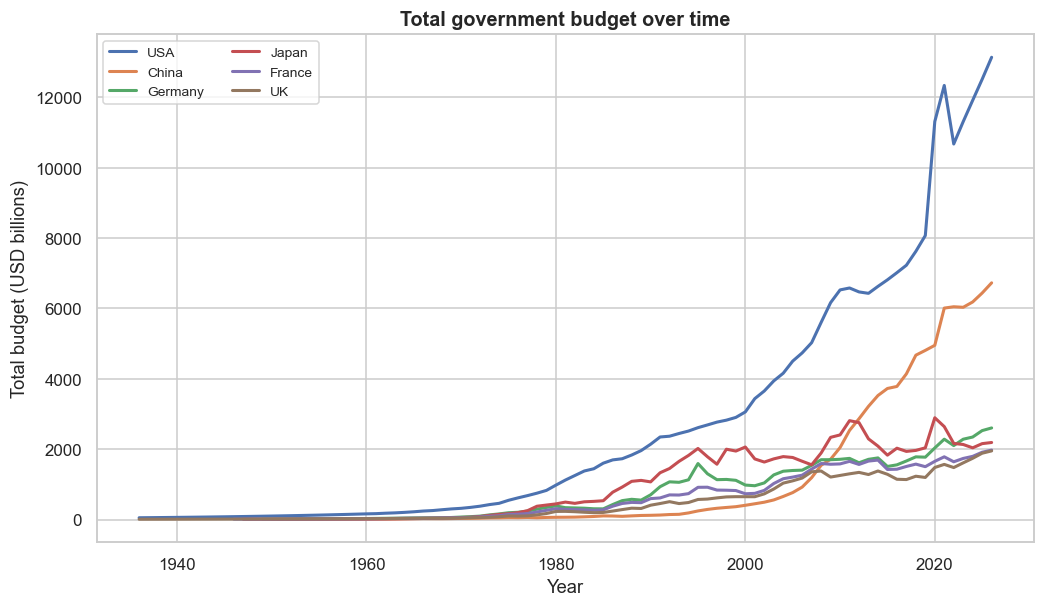

In [3]:
latest = wide.sort_values('Year').groupby('Country').tail(1)
big = latest.nlargest(6, 'Total_Budget_Billions_USD').Country.tolist()
fig, ax = plt.subplots(figsize=(11,6))
viz.plot_total_budget(wide, big, ax=ax)
viz.save(fig, 'viz_total_budget_trends'); plt.show()

## 2. Budget composition over time (stacked area)
How the *mix* of spending shifts within a country.

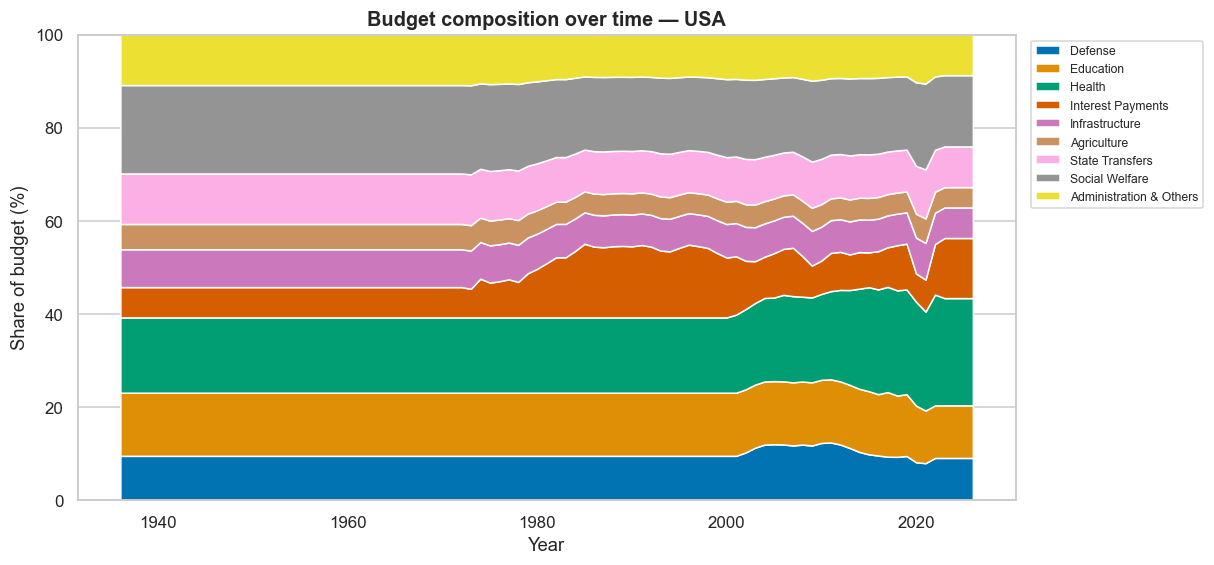

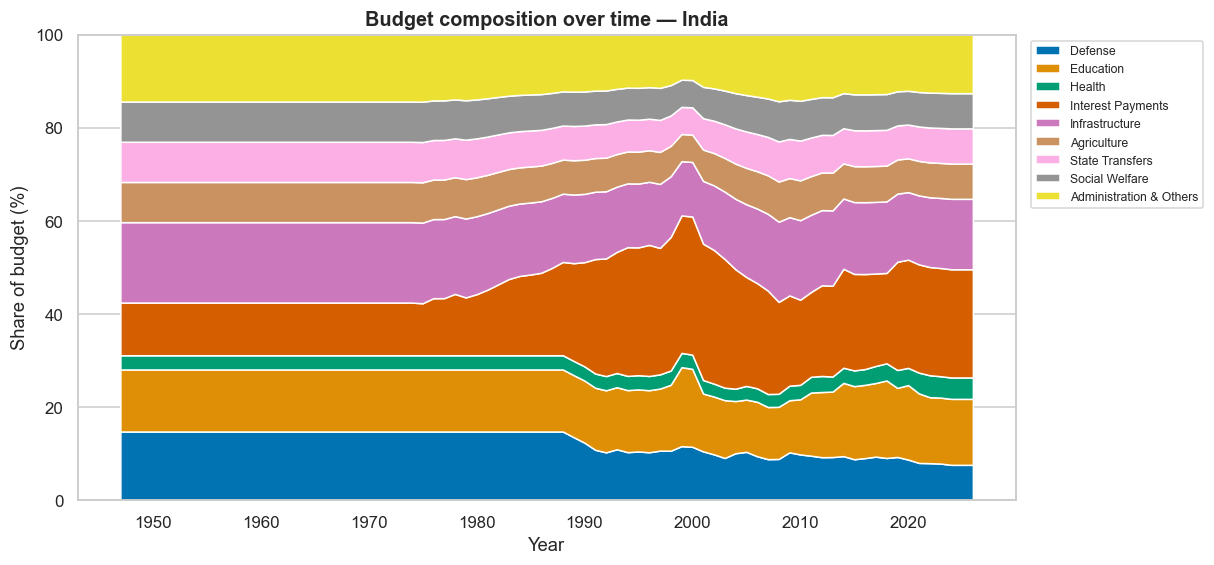

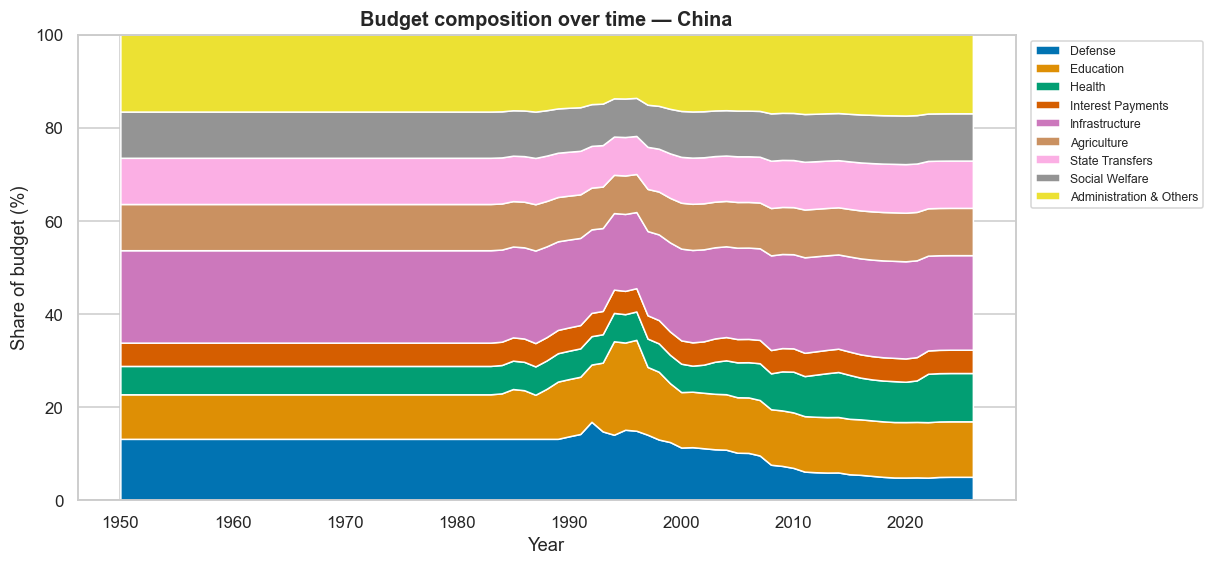

In [4]:
for country in ['USA', 'India', 'China']:
    fig, ax = plt.subplots(figsize=(11,5.5))
    viz.plot_composition(wide, country, ax=ax)
    viz.save(fig, f'viz_composition_{country.lower()}'); plt.show()

## 3. Small multiples — total budget grid
A compact overview across many countries at once.

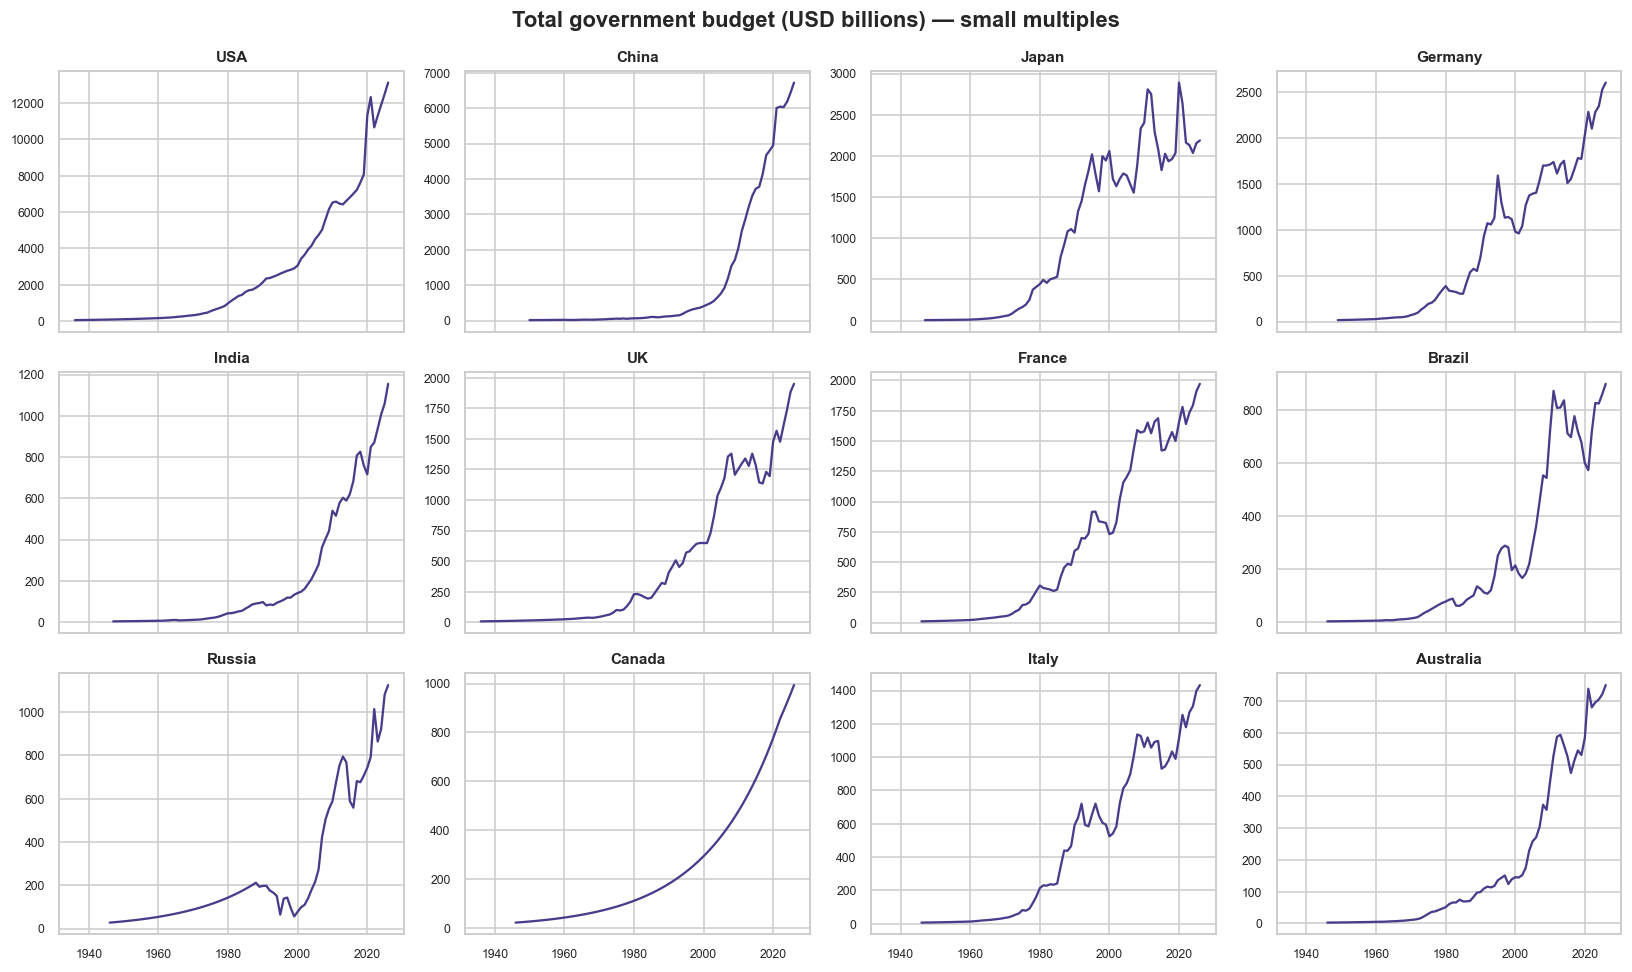

In [5]:
sample = ['USA','China','Japan','Germany','India','UK','France','Brazil','Russia','Canada','Italy','Australia']
fig, axes = plt.subplots(3, 4, figsize=(15,9), sharex=True)
for ax, c in zip(axes.ravel(), sample):
    s = wide[wide.Country==c].sort_values('Year')
    ax.plot(s.Year, s.Total_Budget_Billions_USD, color='darkslateblue')
    ax.set_title(c, fontsize=10); ax.tick_params(labelsize=8)
fig.suptitle('Total government budget (USD billions) — small multiples', fontweight='bold')
fig.tight_layout()
viz.save(fig, 'viz_small_multiples'); plt.show()

## 4. Category heatmaps across countries
Defense and Health shares by country and year — bands reveal regime shifts and priorities.

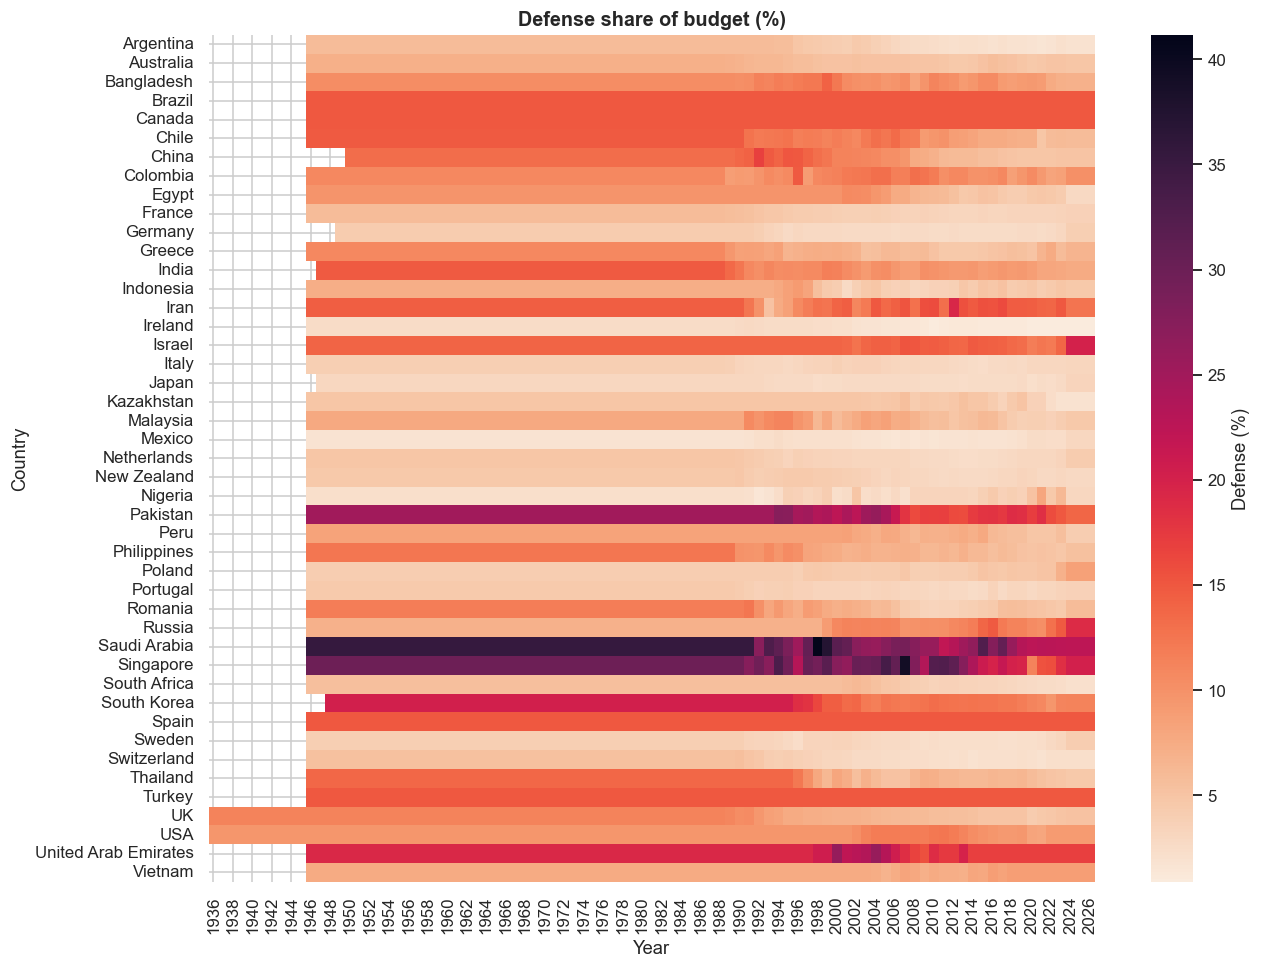

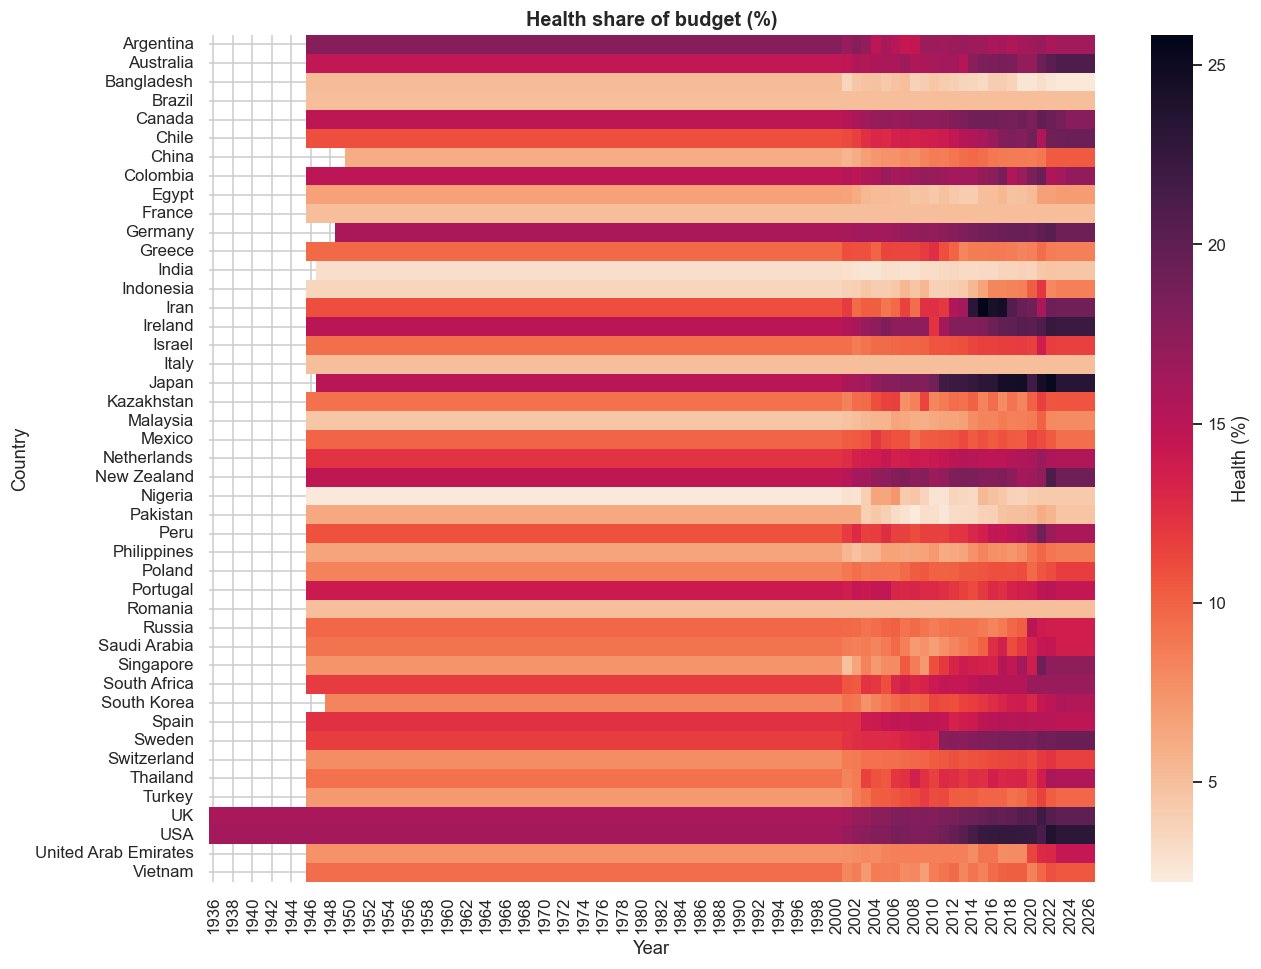

In [6]:
for cat in ['Defense','Health']:
    fig, ax = plt.subplots(figsize=(13,10))
    viz.plot_category_heatmap(wide, cat, ax=ax)
    viz.save(fig, f'viz_heatmap_{cat.lower()}'); plt.show()

## 5. Global average composition, then vs now
Simple cross-country mean of shares, early vs latest period.

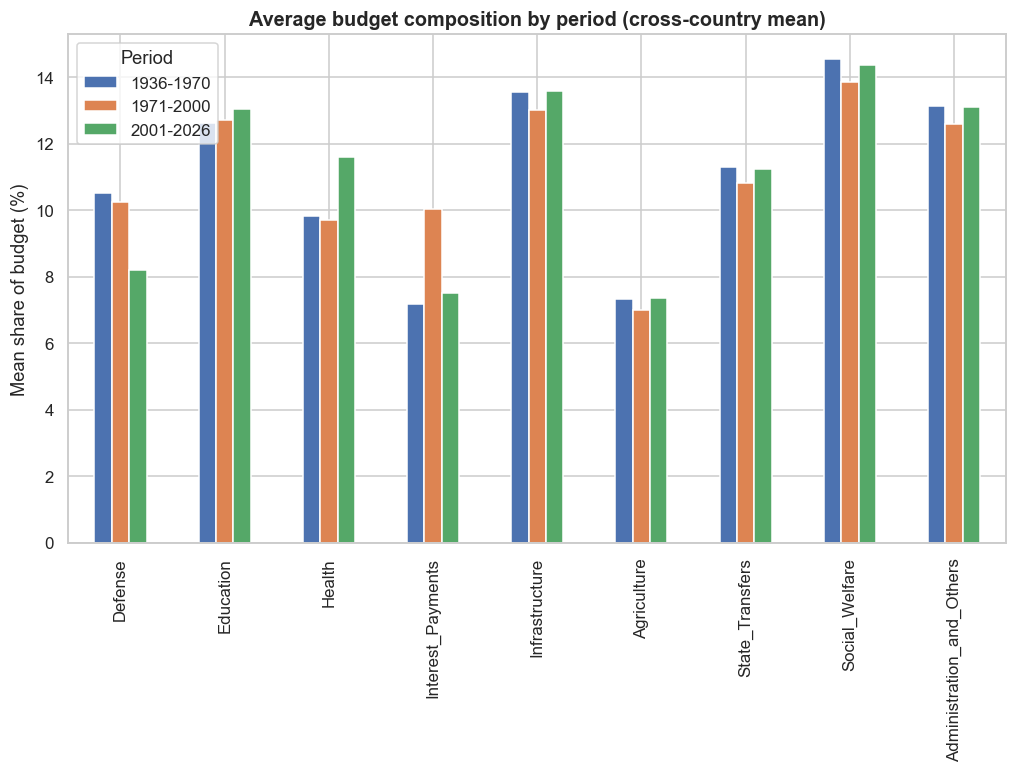

In [7]:
eras = wide.assign(Period=np.where(wide.Year<=1970,'1936-1970', np.where(wide.Year<=2000,'1971-2000','2001-2026')))
pct_cols = data_loader.PCT_COLS
comp = eras.groupby('Period')[pct_cols].mean()
comp.columns = [c.replace('_Percentage','') for c in comp.columns]
fig, ax = plt.subplots(figsize=(11,6))
comp.T.plot(kind='bar', ax=ax)
ax.set_ylabel('Mean share of budget (%)'); ax.set_title('Average budget composition by period (cross-country mean)')
ax.legend(title='Period')
viz.save(fig, 'viz_composition_by_period'); plt.show()

Figures are saved to `reports/figures/`. Next: **03_cross_country** for rankings & clustering.